In [1]:
#here, i'm going to experiment with synthetic data
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import copy


device = torch.device("cpu") #bc i'm doing this in aws, no gpu needed
transform = transforms.ToTensor() #this is a torchvision package for casting images to torch.Tensor
test_ds = datasets.MNIST(root="", train=False, download=True, transform=transform)

test_loader = DataLoader(test_ds, batch_size=56, shuffle=False)
model = nn.Sequential(
    nn.Flatten(), #unsurprisingly, this flattens data 0
    nn.Linear(28*28, 256), #linear layer 1
    nn.ReLU(), # 2
    nn.Linear(256, 128), #squash down 3
    nn.ReLU(), # 4
    nn.Linear(128, 10) #output 5
).to(device)
#each linear layer is an n x n matrix. the first layer is 28*28 whatever values multiplied down to 256 values
model.load_state_dict(torch.load("mlp_mnist_state_dict.pt", map_location=device))

all_labels = []
all_images = []


def get_activations_for_all_digits(model):
    acts = {}
    digit_activations = {x: [] for x in range(10)}

    def save_activation(name):
        def hook(module, inp, out):
            acts[name] = out.detach()
        return hook

    h1 = model[2].register_forward_hook(save_activation("h1"))#create forward hook on this and call it a1
    z2 = model[3].register_forward_hook(save_activation("z2"))
    logits = model[5].register_forward_hook(save_activation("logits"))

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            _ = model(x)

            h1_act = acts.pop("h1")#these are of length(batch) and contain activations for each value in y 
            z2_act = acts.pop("z2")
            logits_act = acts.pop("logits")


            for i in range(len(y)):#iterate through y
                digit = y[i].item()#cast tensor to python int
                digit_activations[digit].append([h1_act[i], z2_act[i], logits_act[i]])#take slices out of a1, a2, and a3

        h1.remove()#remove hooks when done
        z2.remove()
        logits.remove()

        return digit_activations

In [2]:
average_digits = {
    digit: torch.stack([img for img, label in test_ds if label == digit]).mean(dim=0)
    for digit in range(10)
}

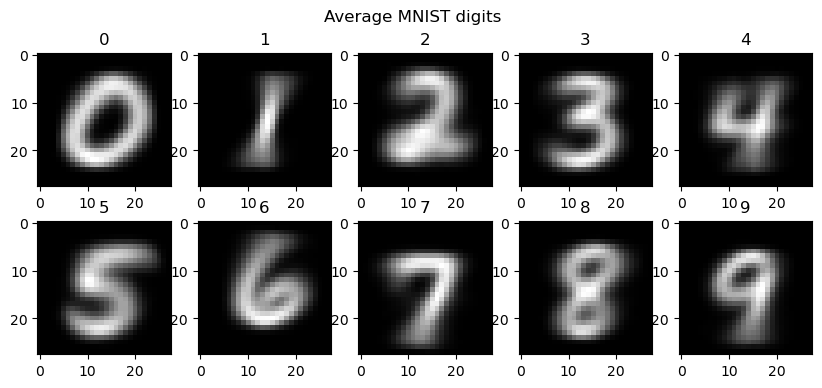

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in zip(range(10), axes.flat):
    ax.imshow(average_digits[digit].squeeze(), cmap="gray")
    ax.set_title(str(digit))

plt.suptitle("Average MNIST digits")
plt.show()

In [4]:
def get_activations_for_image(model, image):
    model.eval()
    acts = {}
    def save_activation(name):
        def hook(module, inp, out):
            acts[name] = out.detach()
        return hook

    handle = model[4].register_forward_hook(save_activation("a2"))

    results = model(image)
    a2_activation = acts.pop("a2")
    
    handle.remove()

    return results, a2_activation

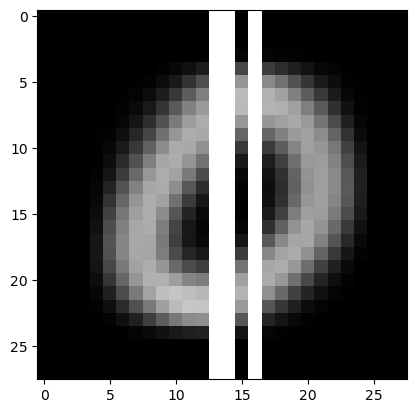

In [24]:
h_barred_0_black = average_digits[0].clone()
h_barred_0_black[0, 14, :] = 0

v_barred_0_black = average_digits[0].clone()
v_barred_0_black[0, :, 14] = 1
v_barred_0_black[0, :, 13] = 1
v_barred_0_black[0, :, 16] = 1

h_barred_0_white = average_digits[0].clone()
h_barred_0_white[0, 14, 5:25] = 1

v_barred_0_white = average_digits[0].clone()
v_barred_0_white[0, 4:25, 14] = 1

plt.imshow(v_barred_0_black.squeeze(), cmap='grey')

In [25]:
v_barred_0_logits_black, v_barred_0_a2_activations_black = get_activations_for_image(model, v_barred_0_black)
h_barred_0_logits_black, h_barred_0_a2_activations_black = get_activations_for_image(model, h_barred_0_black)

v_barred_0_logits_white, v_barred_0_a2_activations_white = get_activations_for_image(model, v_barred_0_white)
h_barred_0_logits_white, h_barred_0_a2_activations_white = get_activations_for_image(model, h_barred_0_white)

normal_0_logits, normal_0_a2_activations = get_activations_for_image(model, average_digits[0])

In [31]:
normal_probs = torch.softmax(normal_0_logits, dim=1).tolist()[0]
v_probs_w = torch.softmax(v_barred_0_logits_white, dim=1).tolist()[0]
h_probs_w = torch.softmax(h_barred_0_logits_white, dim=1).tolist()[0]
v_probs_b = torch.softmax(v_barred_0_logits_black, dim=1).tolist()[0]
h_probs_b = torch.softmax(h_barred_0_logits_black, dim=1).tolist()[0]

In [33]:
max_normal = max(normal_probs)
max_normal_index = normal_probs.index(max_normal)

max_v_w = max(v_probs_w)
max_v_index_w = v_probs_w.index(max_v_w)
max_h_w = max(h_probs_w)
max_h_index_w = h_probs_w.index(max_h_w)

max_v_b = max(v_probs_b)
max_v_index_b = v_probs_b.index(max_v_b)
max_h_b = max(h_probs_b)
max_h_index_b = h_probs_b.index(max_h_b)



print(max_normal, max_normal_index)
print(max_v_b, max_v_index_b)
print(max_h_b, max_h_index_b)
print(max_v_w, max_v_index_w)
print(max_h_w, max_h_index_w)

0.9999183416366577 0
0.7061026096343994 8
0.999873161315918 0
0.9992979764938354 0
0.9994649291038513 0


In [34]:
#despite definitely destroying the loop, the model still is essentially certain that these values are 0s. this quite strongly disproves my hypothesis 

In [35]:
#as zero is the most loopy number, 

In [ ]:
#try putting lines through all loops 

In [ ]:
#1 - zero is a closed loop
#2 - a zero which has a line through it is not a closed loop 
#3 - a zero with a line through it is still recognised as a zero
#4 - therefore, being a closed loop is not used in determining whether a symbol is 0

In [ ]:
#to do - make nice readme + single notebook

In [ ]:
#best hypothesis is that it's essentially a really big if statement
#i.e, if 4, 4 > 0.56 AND 4,3 > 0.89..., then return 0